In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

LOADING THE CLEANED DATASET

In [3]:
orders_products_dt = pd.read_csv("orders_products_dt", index_col=0)

In [4]:
orders_products_dt

,order_id,created_date,total_paid,state,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,discount_%,discount_flag,line_total,paid_vs_line_diff,discount
1,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,1,LAC0212,129.16,2017-11-06 12:47:20,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,1.0,11935397,7.736267,normal,129.16,6.99,10.83
2,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,1,PAR0074,10.77,2017-12-31 17:26:40,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,0.0,11905404,40.133407,normal,10.77,4.99,7.22
3,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,1,OWC0074,77.99,2017-02-15 17:07:44,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1.0,1364,22.002200,normal,77.99,6.99,22.00
5,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,1,TAD0007,149.00,2017-06-28 11:12:30,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,0.0,11905404,16.759777,normal,149.00,0.00,30.00
6,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,2,PAC1561,52.99,2017-01-21 12:49:00,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,1.0,11935397,49.023569,normal,105.98,6.99,50.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257250,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,1,APP0927,13.99,2018-03-14 11:42:38,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,1.0,5384,60.028571,normal,13.99,4.99,21.01
257280,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01
257283,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01
257304,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,29.97,4.99,15.01


In [5]:
# QUICK LOOK AT THE DATA
orders_products_dt

,order_id,created_date,total_paid,state,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,discount_%,discount_flag,line_total,paid_vs_line_diff,discount
1,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,1,LAC0212,129.16,2017-11-06 12:47:20,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,1.0,11935397,7.736267,normal,129.16,6.99,10.83
2,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,1,PAR0074,10.77,2017-12-31 17:26:40,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,0.0,11905404,40.133407,normal,10.77,4.99,7.22
3,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,1,OWC0074,77.99,2017-02-15 17:07:44,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1.0,1364,22.002200,normal,77.99,6.99,22.00
5,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,1,TAD0007,149.00,2017-06-28 11:12:30,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,0.0,11905404,16.759777,normal,149.00,0.00,30.00
6,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,2,PAC1561,52.99,2017-01-21 12:49:00,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,1.0,11935397,49.023569,normal,105.98,6.99,50.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257250,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,1,APP0927,13.99,2018-03-14 11:42:38,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,1.0,5384,60.028571,normal,13.99,4.99,21.01
257280,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01
257283,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01
257304,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,29.97,4.99,15.01


In [6]:
orders_products_dt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54548 entries, 1 to 257318
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           54548 non-null  int64  
 1   created_date       54548 non-null  object 
 2   total_paid         54548 non-null  float64
 3   state              54548 non-null  object 
 4   id                 54548 non-null  int64  
 5   id_order           54548 non-null  int64  
 6   product_quantity   54548 non-null  int64  
 7   sku                54548 non-null  object 
 8   unit_price         54548 non-null  float64
 9   date               54548 non-null  object 
 10  name               54548 non-null  object 
 11  desc               54548 non-null  object 
 12  price              54548 non-null  float64
 13  in_stock           54548 non-null  float64
 14  type               54548 non-null  object 
 15  discount_%         54548 non-null  float64
 16  discount_flag      54548 n

FIXING DATA TYPES

In [7]:
# CONVERTING DATES
orders_products_dt["created_date"] = pd.to_datetime(orders_products_dt["created_date"])
orders_products_dt["date"] = pd.to_datetime(orders_products_dt["date"])

In [8]:
orders_products_dt["discount"] = orders_products_dt["price"] - orders_products_dt["unit_price"]

In [9]:
orders_products_dt

,order_id,created_date,total_paid,state,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,discount_%,discount_flag,line_total,paid_vs_line_diff,discount
1,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,1,LAC0212,129.16,2017-11-06 12:47:20,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,1.0,11935397,7.736267,normal,129.16,6.99,10.83
2,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,1,PAR0074,10.77,2017-12-31 17:26:40,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,0.0,11905404,40.133407,normal,10.77,4.99,7.22
3,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,1,OWC0074,77.99,2017-02-15 17:07:44,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1.0,1364,22.002200,normal,77.99,6.99,22.00
5,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,1,TAD0007,149.00,2017-06-28 11:12:30,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,0.0,11905404,16.759777,normal,149.00,0.00,30.00
6,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,2,PAC1561,52.99,2017-01-21 12:49:00,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,1.0,11935397,49.023569,normal,105.98,6.99,50.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257250,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,1,APP0927,13.99,2018-03-14 11:42:38,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,1.0,5384,60.028571,normal,13.99,4.99,21.01
257280,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01
257283,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01
257304,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,29.97,4.99,15.01


In [10]:
# DROPPING NEGATIVE DISCOUNTS (UNIT_PRICE > PRICE ANOMALIES)
orders_products_dt = orders_products_dt.loc[orders_products_dt["discount"] >= 0]
orders_products_dt.shape

(54548, 20)

In [11]:
#DROPPING ROWS WITH UNIT PRICE * QUANTITY THAT ARE BIGGER THAN TOTAL PAID
orders_products_dt = orders_products_dt.loc[(orders_products_dt["unit_price"] * orders_products_dt["product_quantity"])
                                            <=
                                            orders_products_dt["total_paid"]]

In [12]:
orders_products_dt.loc[(orders_products_dt["unit_price"] * orders_products_dt["product_quantity"])
                                            >
                                            orders_products_dt["total_paid"]]

,order_id,created_date,total_paid,state,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,discount_%,discount_flag,line_total,paid_vs_line_diff,discount


# ANALYSING
## HOW MANY PRODUCTS ARE BEING DISCOUNTED?

In [13]:
# COUNTING DISCOUNTED VS NOT DISCOUNTED
orders_products_dt.loc[orders_products_dt["discount"] > 0].shape[0]

51833

In [14]:
# CHECKING THE PERCENTAGE
round((orders_products_dt.loc[orders_products_dt["discount"] > 0].shape[0]
       /
       orders_products_dt.shape[0]) * 100, 2)
# AROUND 95.15% OF ORDER LINES ARE DISCOUNTED

95.54

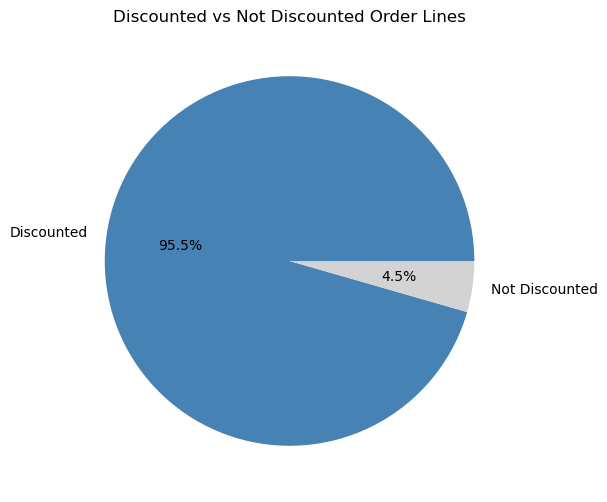

In [15]:
# MAKING A SIMPLE PIE CHART TO VISUALISE IT
discounted_count = orders_products_dt.loc[orders_products_dt["discount"] > 0].shape[0]
not_discounted_count = orders_products_dt.loc[orders_products_dt["discount"] == 0].shape[0]

plt.figure(figsize=(6, 6))
plt.pie([discounted_count, not_discounted_count],
        labels=["Discounted", "Not Discounted"],
        autopct="%1.1f%%",
        colors=["steelblue", "lightgray"])
plt.title("Discounted vs Not Discounted Order Lines")
plt.show()

##  HOW BIG ARE THE DISCOUNTS?

In [16]:
# LOOKING AT THE DISCOUNT % STATS
orders_products_dt.loc[orders_products_dt["discount"] > 0, "discount_%"].describe().round(2)
# THE MEAN IS AROUND 20.42% MEANING MOST DISCOUNTS ARE MODEST NOT AGGRESSIVE

count    51833.00
mean        22.40
std         15.78
min          0.00
25%         11.09
50%         19.36
75%         29.31
max         74.84
Name: discount_%, dtype: float64

In [17]:
# CHECKING HOW MANY HAVE EXTREME DISCOUNTS OVER 50%
orders_products_dt.loc[orders_products_dt["discount_%"] > 50].shape[0]
# ONLY A SMALL FRACTION HAVE EXTREME DISCOUNTS

4405

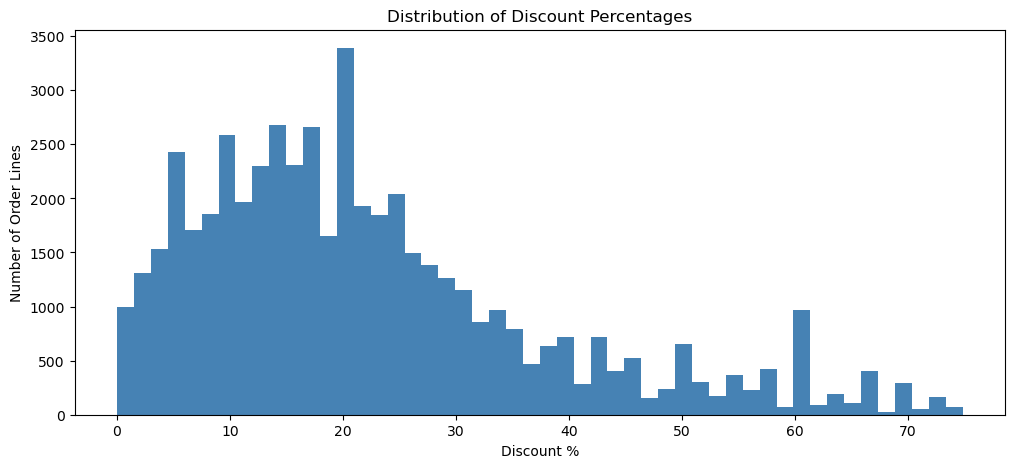

In [18]:
# PLOTTING THE DISCOUNT % DISTRIBUTION
discounts_only = orders_products_dt.loc[orders_products_dt["discount"] > 0]

discounts_only["discount_%"].plot(kind="hist",
                                  bins=50,
                                  figsize=(12, 5),
                                  color="steelblue",
                                  edgecolor="none")
plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount %")
plt.ylabel("Number of Order Lines")
plt.show()

In [19]:
# GROUPING DISCOUNTS INTO BANDS TO MAKE IT CLEARER
discounts_only = discounts_only.copy()
discounts_only["disc_band"] = pd.cut(discounts_only["discount_%"],
                                      bins=[0, 10, 25, 50, 75, 100],
                                      labels=["0-10%", "10-25%", "25-50%", "50-75%", "75-100%"])

discounts_only["disc_band"].value_counts().sort_index()

disc_band
0-10%      11090
10-25%     23091
25-50%     13247
50-75%      4405
75-100%        0
Name: count, dtype: int64

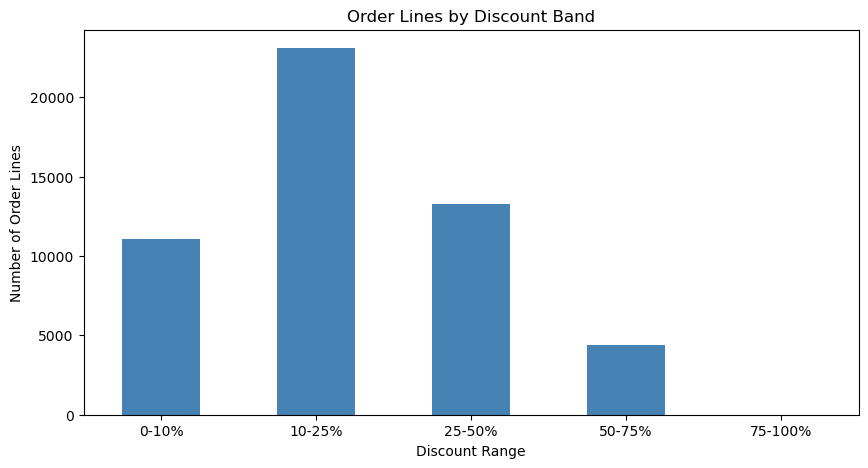

In [20]:
# PLOTTING THE BANDS
discounts_only["disc_band"].value_counts().sort_index().plot(kind="bar",
                                                              figsize=(10, 5),
                                                              color="steelblue")
plt.title("Order Lines by Discount Band")
plt.xlabel("Discount Range")
plt.ylabel("Number of Order Lines")
plt.xticks(rotation=0)
plt.show()
# 10-25% IS THE MOST COMMON DISCOUNT RANGE

##  HOW DOES SEASONALITY AFFECT SALES?

In [21]:
# CHECKING THE SUM OF UNIT_PRICE OVER TIME (MONTHLY)
unit_price_month = orders_products_dt.resample("ME", on="created_date")["unit_price"].sum()
unit_price_month

created_date
2017-01-31     500391.16
2017-02-28     276198.60
2017-03-31      20023.74
2017-04-30     211450.23
2017-05-31     278376.89
2017-06-30     248136.87
2017-07-31     549794.41
2017-08-31     353532.41
2017-09-30     361984.77
2017-10-31     520052.06
2017-11-30    1458854.25
2017-12-31     971607.48
2018-01-31     821463.41
2018-02-28     512211.37
2018-03-31     215643.96
Freq: ME, Name: unit_price, dtype: float64

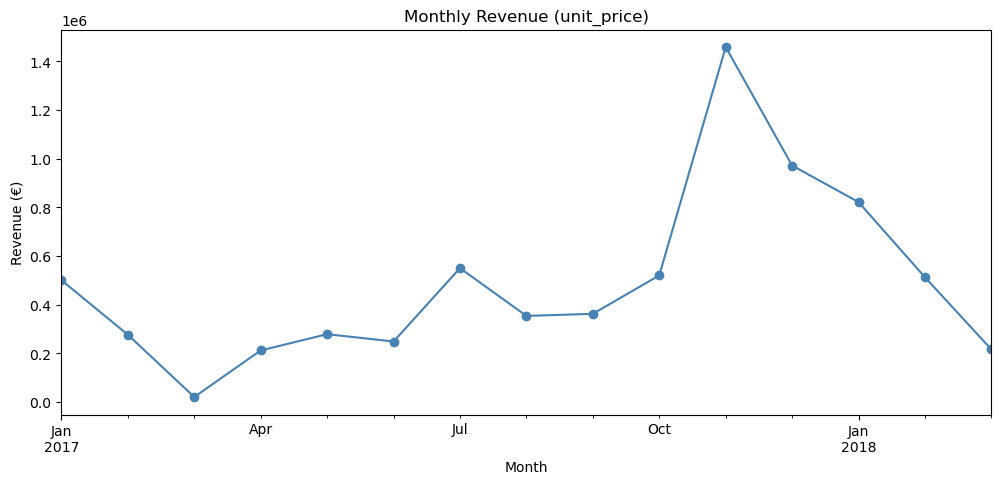

In [22]:
# PLOTTING TO UNDERSTAND THE SEASONALITY
unit_price_month.plot(figsize=(12, 5), color="steelblue", marker="o")
plt.title("Monthly Revenue (unit_price)")
plt.ylabel("Revenue (€)")
plt.xlabel("Month")
plt.show()
# NOVEMBER 2017 IS A CLEAR SPIKE - BLACK FRIDAY
# DECEMBER AND JANUARY ARE ALSO HIGH - CHRISTMAS AND POST HOLIDAY

In [23]:
# CHECKING HOW MANY ORDERS PER MONTH
orders_month = orders_products_dt.resample("ME", on="created_date")["order_id"].nunique()
orders_month

created_date
2017-01-31    4331
2017-02-28    1980
2017-03-31     155
2017-04-30    1448
2017-05-31    1646
2017-06-30    1370
2017-07-31    3109
2017-08-31    2145
2017-09-30    1896
2017-10-31    2726
2017-11-30    6573
2017-12-31    5024
2018-01-31    4597
2018-02-28    2967
2018-03-31    1408
Freq: ME, Name: order_id, dtype: int64

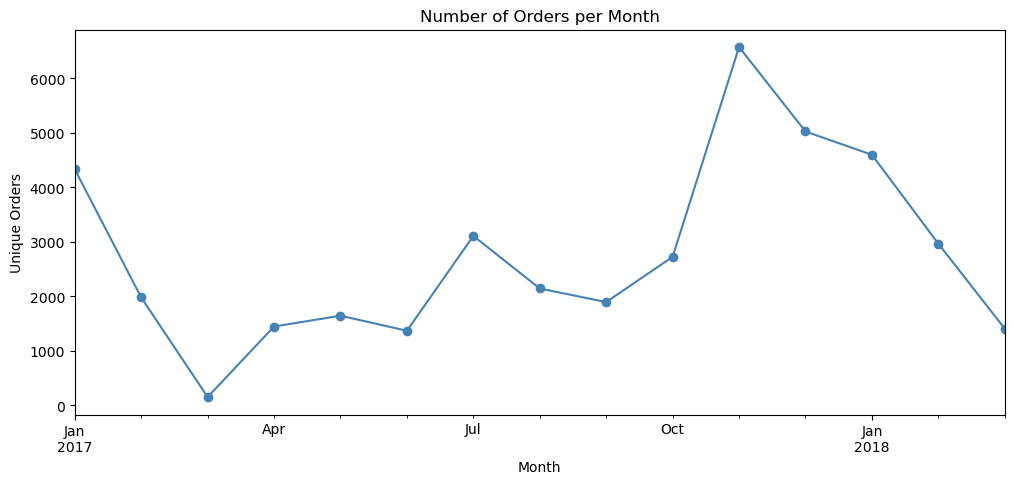

In [24]:
orders_month.plot(figsize=(12, 5), color="steelblue", marker="o")
plt.title("Number of Orders per Month")
plt.ylabel("Unique Orders")
plt.xlabel("Month")
plt.show()

In [25]:
# CHECKING THE AVERAGE DISCOUNT % PER MONTH
disc_month = orders_products_dt.resample("ME", on="created_date")["discount_%"].mean()
disc_month

created_date
2017-01-31    25.177090
2017-02-28    20.709540
2017-03-31    20.654217
2017-04-30    18.959513
2017-05-31    16.954180
2017-06-30    18.562096
2017-07-31    25.650726
2017-08-31    20.917299
2017-09-30    19.976991
2017-10-31    19.903140
2017-11-30    21.943054
2017-12-31    19.630338
2018-01-31    21.877182
2018-02-28    20.134406
2018-03-31    21.686010
Freq: ME, Name: discount_%, dtype: float64

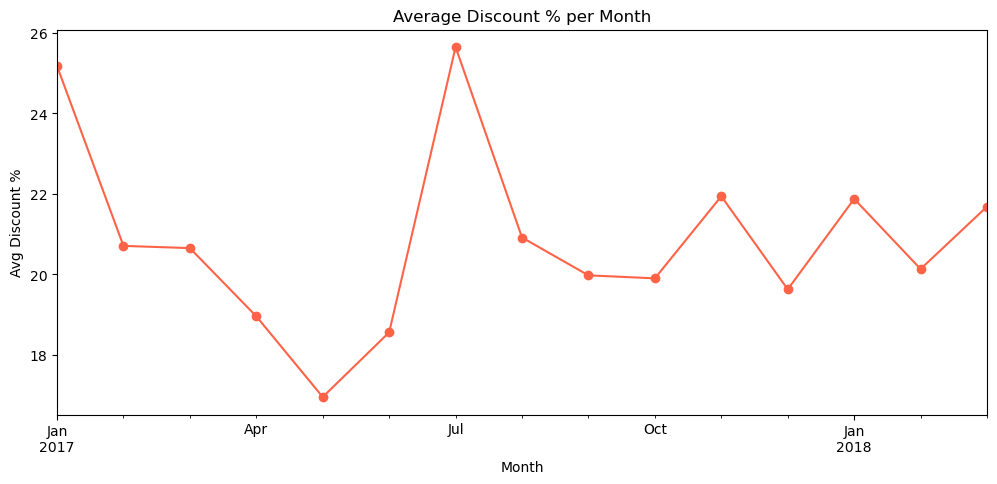

In [26]:
disc_month.plot(figsize=(12, 5), color="tomato", marker="o")
plt.title("Average Discount % per Month")
plt.ylabel("Avg Discount %")
plt.xlabel("Month")
plt.show()
# INTERESTING: NOVEMBER HAS HIGH REVENUE BUT NOT THE HIGHEST DISCOUNT %
# VOLUME DRIVEN NOT JUST BY DISCOUNTS

In [27]:
# COMPARING DISCOUNTED VS NOT DISCOUNTED REVENUE OVER TIME
discounts_plot = orders_products_dt.loc[orders_products_dt["discount"] > 0].resample(
    "ME", on="created_date")["unit_price"].sum()

undiscounts_plot = orders_products_dt.loc[orders_products_dt["discount"] == 0].resample(
    "ME", on="created_date")["unit_price"].sum()

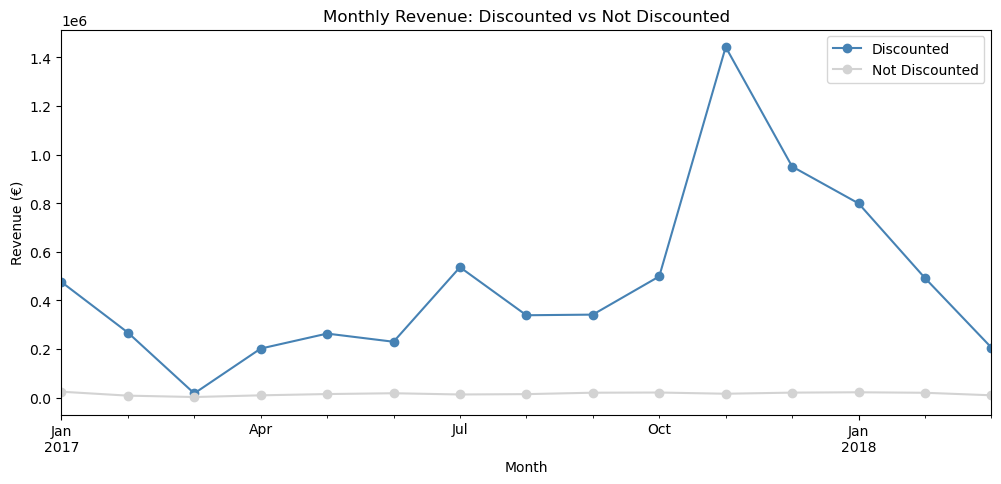

In [28]:
# PLOTTING BOTH TOGETHER
fig, ax = plt.subplots(figsize=(12, 5))
discounts_plot.plot(ax=ax, label="Discounted", color="steelblue", marker="o")
undiscounts_plot.plot(ax=ax, label="Not Discounted", color="lightgray", marker="o")
plt.title("Monthly Revenue: Discounted vs Not Discounted")
plt.ylabel("Revenue (€)")
plt.xlabel("Month")
plt.legend()
plt.show()
# DISCOUNTED PRODUCTS DRIVE MOST OF THE REVENUE

## DOES DISCOUNT DEPTH DRIVE MONTHLY REVENUE?

In [29]:
monthly = orders_products_dt.resample("ME", on="created_date").agg(
    avg_discount=("discount_%", "mean"),
    total_revenue=("unit_price", "sum")
).reset_index()

In [30]:
# Calculating correlation
correlation = monthly["avg_discount"].corr(monthly["total_revenue"])
print(f"Correlation between monthly discount depth and revenue: {correlation:.2f}")


Correlation between monthly discount depth and revenue: 0.26


In [31]:
month_labels = monthly["created_date"].dt.strftime("%b %y")

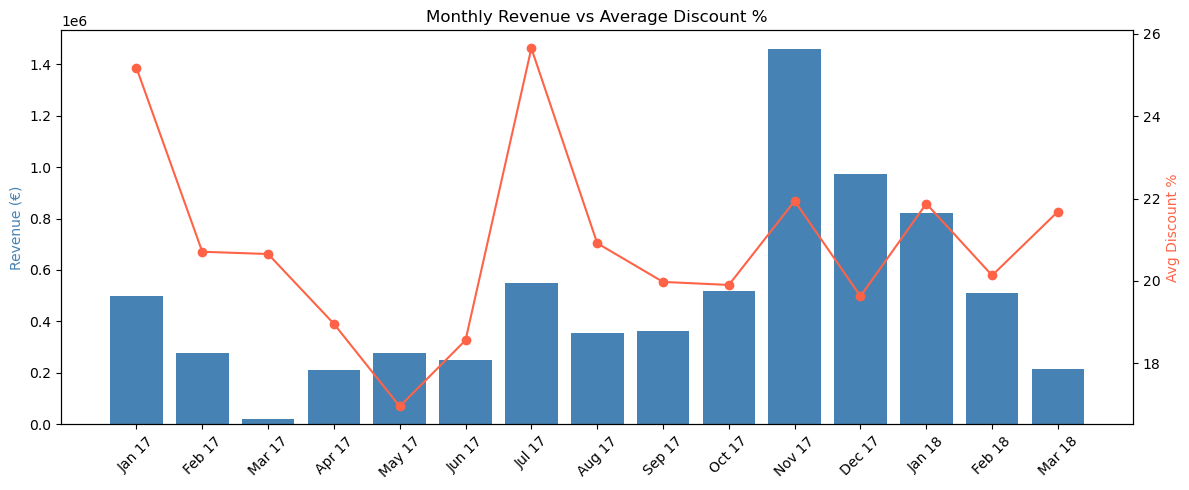

In [32]:
# Plotting it
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(month_labels, monthly["total_revenue"], color="steelblue", label="Revenue")
ax1.set_ylabel("Revenue (€)", color="steelblue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(month_labels, monthly["avg_discount"], color="tomato", marker="o", label="Avg Discount %")
ax2.set_ylabel("Avg Discount %", color="tomato")

plt.title("Monthly Revenue vs Average Discount %")
plt.tight_layout()
plt.show()

<!-- ## HOW SHOULD PRODUCTS BE CLASSIFIED INTO CATEGORIES? -->

## HOW SHOULD PRODUCTS BE ClASSIFIED INTO CATEGORIES?

In [33]:
# LOOKING AT THE TYPE COLUMN
orders_products_dt["type"].nunique()
# 126 UNIQUE TYPE CODES - SOME ARE HUMAN READABLE

116

In [34]:
# MOST COMMON TYPE CODES
orders_products_dt["type"].value_counts().head(10)

type
11865403    4206
11935397    3845
1364        3189
11905404    3111
5384        2403
12585395    2162
12215397    2075
12655397    1887
1230        1459
1296        1424
Name: count, dtype: int64

In [35]:
orders_products_dt[["name","desc" ]]

,name,desc
1,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...
2,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones
3,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...
5,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...
6,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...
...,...,...
257250,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...
257280,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...
257283,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...
257304,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...


In [36]:
orders_products_dt

,order_id,created_date,total_paid,state,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,discount_%,discount_flag,line_total,paid_vs_line_diff,discount
1,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,1,LAC0212,129.16,2017-11-06 12:47:20,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,1.0,11935397,7.736267,normal,129.16,6.99,10.83
2,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,1,PAR0074,10.77,2017-12-31 17:26:40,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,0.0,11905404,40.133407,normal,10.77,4.99,7.22
3,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,1,OWC0074,77.99,2017-02-15 17:07:44,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1.0,1364,22.002200,normal,77.99,6.99,22.00
5,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,1,TAD0007,149.00,2017-06-28 11:12:30,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,0.0,11905404,16.759777,normal,149.00,0.00,30.00
6,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,2,PAC1561,52.99,2017-01-21 12:49:00,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,1.0,11935397,49.023569,normal,105.98,6.99,50.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257250,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,1,APP0927,13.99,2018-03-14 11:42:38,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,1.0,5384,60.028571,normal,13.99,4.99,21.01
257280,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01
257283,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01
257304,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,60.040000,normal,29.97,4.99,15.01


In [37]:
# CLASSIFYING PRODUCTS USING KEYWORDS FROM THE NAME COLUMN
# SINCE THE TYPE CODES ARE NOT READABLE WE USE THE PRODUCT NAME INSTEAD

def get_category(name, type):
    # --- type ID overrides (take priority) ---
    type_id = str(type)
    if "1716" in type_id:               return "iPhone",        "Mobile"
    if type == "11865403":              return "Cases",         "Accessories"
    if type == "1364":                  return "RAM & Memory",  "Storage"
    if "5397" in type_id:               return "Hard Drives",   "Storage"

    # --- name-based categorization ---
    n = name.lower()

    # devices
    if "macbook pro" in n:              return "MacBook Pro",   "Laptops"
    if "macbook air" in n:              return "MacBook Air",   "Laptops"
    if "macbook" in n:                  return "MacBook",       "Laptops"
    if "imac" in n:                     return "iMac",          "Desktops"
    if "mac mini" in n:                 return "Mac Mini",      "Desktops"
    if "ipad" in n:                     return "iPad",          "Ipad"
    if "ipod" in n:                     return "iPod",          "Ipod"
    if "apple watch" in n:              return "Apple Watch",   "Wearables"
    if "airpod" in n:                   return "AirPods",       "Wearables"
    if "apple tv" in n:                 return "Apple TV",      "Smart Home"

    # storage
    if "hard drive" in n or "hdd" in n: return "Hard Drives",  "Storage"
    if "ssd" in n:                      return "SSD",           "Storage"
    if "nas" in n:                      return "NAS & Servers", "Storage"
    if "memory card" in n or "sdxc" in n or "flash drive" in n:
                                        return "Memory Cards",  "Storage"
    if "ram" in n or "ddr" in n:        return "RAM & Memory",  "Storage"

    # audio
    if "headphone" in n or "headset" in n: return "Headphones","Audio"
    if "speaker" in n:                  return "Speakers",      "Audio"
    if "microphone" in n:               return "Microphones",   "Audio"

    # accessories
    if "keyboard" in n:                 return "Keyboards",     "Accessories"
    if "mouse" in n or "magic mouse" in n: return "Mouse",     "Accessories"
    if "monitor" in n or "display" in n: return "Monitors",    "Displays"
    if "cable" in n or "thunderbolt" in n: return "Cables",    "Accessories"
    if "adapter" in n or "dongle" in n: return "Adapters",     "Accessories"
    if "case" in n or "cover" in n:     return "Cases",        "Accessories"
    if "bag" in n or "sleeve" in n or "backpack" in n:
                                        return "Bags & Cases",  "Accessories"
    if "stand" in n or "mount" in n:    return "Stands",       "Accessories"
    if "stylus" in n or "pencil" in n:  return "Stylus",       "Accessories"

    # power
    if "battery" in n:                  return "Batteries",     "Power"
    if "power bank" in n:               return "Power Banks",   "Power"
    if "charging" in n or "charger" in n: return "Chargers",   "Power"
    if "ups" in n:                      return "UPS",           "Power"

    # smart home & services
    if "sensor" in n or "fibaro" in n or "hue" in n:
                                        return "Smart Home",    "Smart Home"
    if "camera" in n:                   return "Camera",        "Smart Home"
    if "applecare" in n:                return "AppleCare",     "Services"
    if "repair" in n or "ifixit" in n:  return "Repair Tools",  "Services"
    if "software" in n or "office" in n: return "Software",    "Services"

    return "Other", "Other"


orders_products_dt[["category", "category_parent"]] = orders_products_dt.apply(
    lambda row: pd.Series(get_category(row["name"], row["type"])), axis=1)
orders_products_dt["category_parent"].value_counts()

category_parent
Storage        14575
Accessories    10431
Other           7370
Laptops         4490
Ipad            3295
Audio           2721
Mobile          2199
Displays        1847
Wearables       1725
Desktops        1628
Power           1605
Services        1132
Smart Home       964
Ipod             268
Name: count, dtype: int64

In [38]:
orders_products_dt[orders_products_dt["category_parent"] == "Mobile"]

,order_id,created_date,total_paid,state,id,id_order,product_quantity,sku,unit_price,date,...,price,in_stock,type,discount_%,discount_flag,line_total,paid_vs_line_diff,discount,category,category_parent
83,265968,2017-09-04 18:32:57,470.33,Completed,1345025,265968,1,APP1973,470.33,2017-09-04 18:28:35,...,529.00,1.0,51601716,11.090737,normal,470.33,0.00,58.67,iPhone,Mobile
87,267014,2017-11-22 12:00:54,302.39,Completed,1421247,267014,1,AP20305,249.35,2017-11-22 11:33:12,...,419.00,0.0,51601716,40.489260,normal,249.35,53.04,169.65,iPhone,Mobile
120,278926,2017-11-23 11:06:39,795.85,Completed,1406806,278926,1,APP2483,728.12,2017-11-13 18:00:29,...,919.00,1.0,113281716,20.770403,normal,728.12,67.73,190.88,iPhone,Mobile
188,294377,2017-10-05 23:10:10,687.21,Completed,1371033,294377,1,APP2479,667.22,2017-10-05 21:18:51,...,809.00,1.0,113291716,17.525340,normal,667.22,19.99,141.78,iPhone,Mobile
1398,300665,2017-01-02 16:00:16,741.44,Completed,1121579,300665,1,APP1652,726.45,2017-01-02 15:51:20,...,749.00,1.0,85641716,3.010681,normal,726.45,14.99,22.55,iPhone,Mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256219,525996,2018-03-12 16:02:46,448.92,Completed,1647264,525996,1,AP20321,428.93,2018-03-12 15:44:24,...,639.00,0.0,85641716,32.874804,normal,428.93,19.99,210.07,iPhone,Mobile
256243,526015,2018-03-12 16:16:20,382.99,Completed,1647308,526015,1,APP2446,379.00,2018-03-12 16:12:36,...,449.33,0.0,21561716,15.652193,normal,379.00,3.99,70.33,iPhone,Mobile
256268,526042,2018-03-12 17:10:13,945.99,Completed,1647377,526042,1,AP20457,939.00,2018-03-12 17:04:20,...,1089.00,0.0,113281716,13.774105,normal,939.00,6.99,150.00,iPhone,Mobile
256275,526049,2018-03-13 16:11:56,439.99,Completed,1647389,526049,1,APP2446,379.00,2018-03-12 17:21:33,...,449.33,0.0,21561716,15.652193,normal,379.00,60.99,70.33,iPhone,Mobile


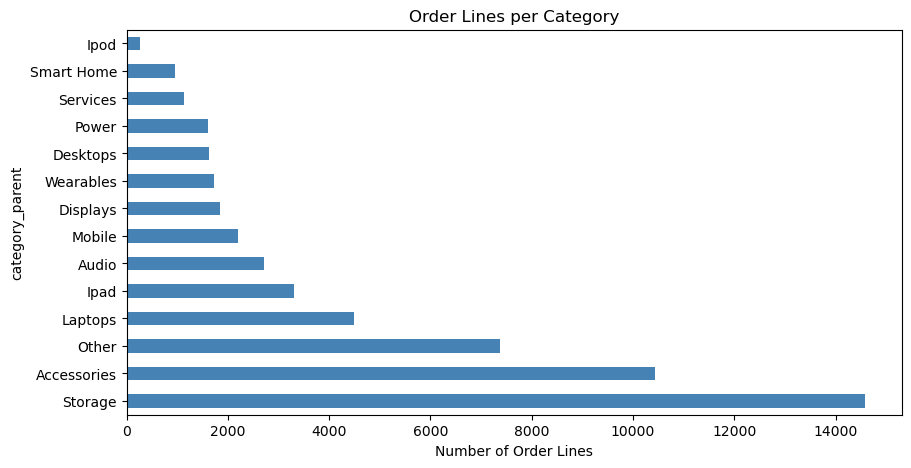

In [39]:
# PLOTTING THE CATEGORY DISTRIBUTION
orders_products_dt["category_parent"].value_counts().plot(kind="barh",
                                                    figsize=(10, 5),
                                                    color="steelblue")
plt.title("Order Lines per Category")
plt.xlabel("Number of Order Lines")
plt.show()

##  WHAT IS THE PRICE DISTRIBUTION ACROSS CATEGORIES?

In [40]:
# MEDIAN PRICE PER CATEGORY
orders_products_dt.groupby("category_parent")["price"].median().sort_values(ascending=False)

category_parent
Mobile         529.00
Displays       269.99
Storage        139.95
Ipad            99.99
Audio           99.95
Laptops         89.00
Desktops        72.99
Services        70.00
Wearables       69.99
Other           59.95
Smart Home      59.95
Accessories     39.00
Power           34.95
Ipod            25.00
Name: price, dtype: float64

In [41]:
# MEDIAN PAID PRICE (UNIT_PRICE) PER CATEGORY
orders_products_dt.groupby("category_parent")["unit_price"].median().sort_values(ascending=False)

category_parent
Mobile         470.33
Displays       237.00
Storage        115.99
Ipad            73.09
Audio           69.99
Laptops         59.99
Wearables       56.99
Services        54.00
Desktops        49.99
Other           49.58
Smart Home      48.59
Accessories     29.74
Power           19.99
Ipod            16.99
Name: unit_price, dtype: float64

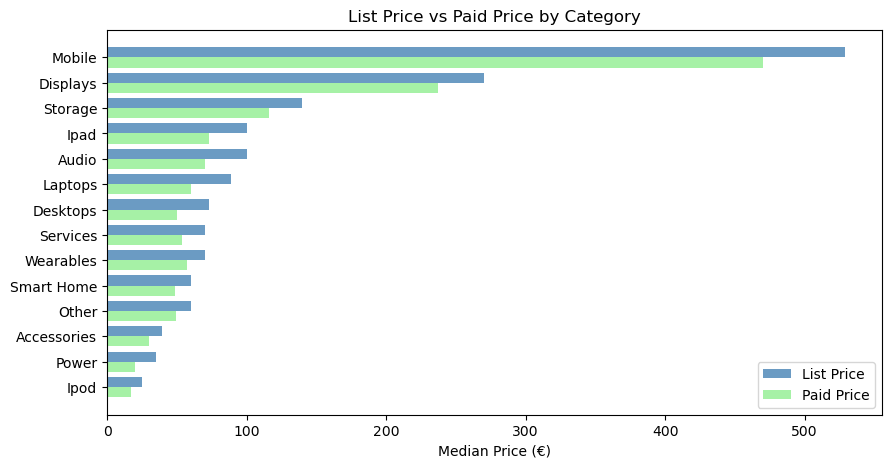

In [42]:
# PLOTTING PRICE VS PAID PRICE PER CATEGORY
cat_price = orders_products_dt.groupby("category_parent")["price"].median().sort_values()
cat_paid = orders_products_dt.groupby("category_parent")["unit_price"].median().reindex(cat_price.index)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(cat_price))
ax.barh([i + 0.2 for i in x], cat_price.values, 0.4, label="List Price", color="steelblue", alpha=0.8)
ax.barh([i - 0.2 for i in x], cat_paid.values, 0.4, label="Paid Price", color="lightgreen", alpha=0.8)
ax.set_yticks(list(x))
ax.set_yticklabels(cat_price.index)
ax.set_xlabel("Median Price (€)")
ax.set_title("List Price vs Paid Price by Category")
ax.legend()
plt.show()
# THE GAP BETWEEN THE BARS IS THE DISCOUNT

In [43]:
# CHECKING AVERAGE DISCOUNT % PER CATEGORY
orders_products_dt.groupby("category_parent")["discount_%"].mean().sort_values(ascending=False).round(2)

category_parent
Audio          29.57
Laptops        26.13
Accessories    25.70
Power          25.34
Ipad           22.73
Desktops       21.22
Other          21.05
Wearables      21.00
Ipod           20.34
Displays       19.94
Services       19.41
Storage        17.12
Smart Home     15.72
Mobile         11.29
Name: discount_%, dtype: float64

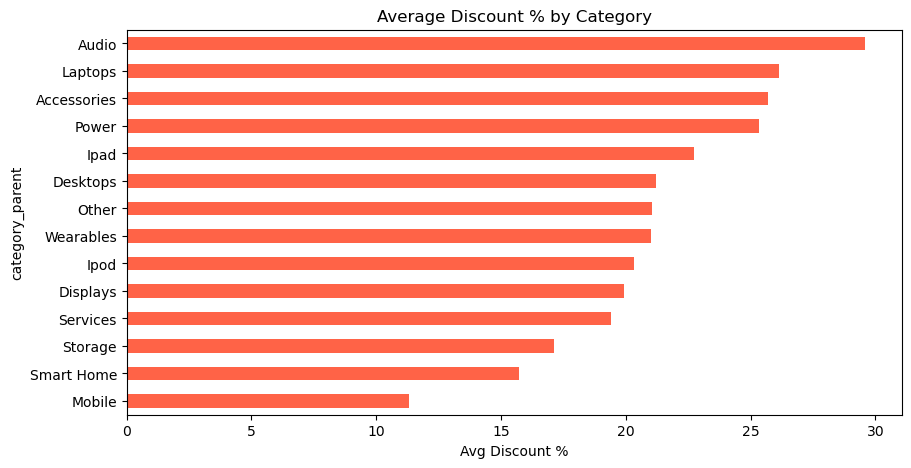

In [44]:
# PLOTTING DISCOUNT % PER CATEGORY
orders_products_dt.groupby("category_parent")["discount_%"].mean().sort_values().plot(
    kind="barh", figsize=(10, 5), color="tomato")
plt.title("Average Discount % by Category")
plt.xlabel("Avg Discount %")
plt.show()

C:\Users\abssi\AppData\Local\Temp\ipykernel_5864\942531868.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rev, y="category_parent", x="revenue_pct",
C:\Users\abssi\AppData\Local\Temp\ipykernel_5864\942531868.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=disc, y="category_parent", x="avg_disc",


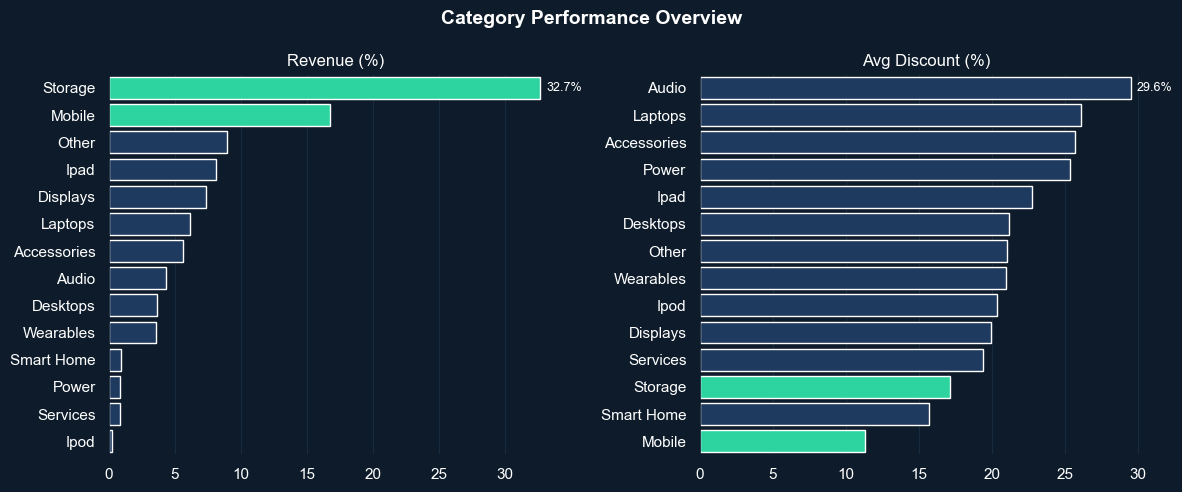

In [69]:
HIGHLIGHT = {"Storage", "Mobile"}

# ── Data prep ──────────────────────────────────────────────────────────────────
rev = orders_products_dt.groupby("category_parent", as_index=False)["unit_price"].sum()
rev["revenue_pct"] = rev["unit_price"] / rev["unit_price"].sum() * 100
rev = rev.sort_values("revenue_pct", ascending=False)

disc = (
    orders_products_dt.groupby("category_parent", as_index=False)["discount_%"]
    .mean()
    .rename(columns={"discount_%": "avg_disc"})
    .sort_values("avg_disc", ascending=False)
)

# ── Theme ──────────────────────────────────────────────────────────────────────
BG   = "#0d1b2a"
TEAL = "#2dd4a0"
NAVY = "#1e3a5f"

sns.set_theme(style="darkgrid", rc={
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.edgecolor":    BG,
    "axes.labelcolor":   "white",
    "text.color":        "white",
    "xtick.color":       "white",
    "ytick.color":       "white",
    "grid.color":        "#1a2f45",
    "grid.linewidth":    0.6,
})

def bar_colors(labels):
    return [TEAL if l in HIGHLIGHT else NAVY for l in labels]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Category Performance Overview", color="white", fontsize=14, fontweight="bold")

sns.barplot(data=rev, y="category_parent", x="revenue_pct",
            palette=bar_colors(rev["category_parent"]), ax=ax1, saturation=1)
ax1.set(title="Revenue (%)", xlabel="", ylabel="")
ax1.bar_label(ax1.containers[0], fmt="%.1f%%", padding=4, fontsize=9, color="white")

sns.barplot(data=disc, y="category_parent", x="avg_disc",
            palette=bar_colors(disc["category_parent"]), ax=ax2, saturation=1)
ax2.set(title="Avg Discount (%)", xlabel="", ylabel="")
ax2.bar_label(ax2.containers[0], fmt="%.1f%%", padding=4, fontsize=9, color="white")

plt.tight_layout()
plt.show()

In [46]:
orders_products_dt

,order_id,created_date,total_paid,state,id,id_order,product_quantity,sku,unit_price,date,...,price,in_stock,type,discount_%,discount_flag,line_total,paid_vs_line_diff,discount,category,category_parent
1,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,1,LAC0212,129.16,2017-11-06 12:47:20,...,139.99,1.0,11935397,7.736267,normal,129.16,6.99,10.83,Hard Drives,Storage
2,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,1,PAR0074,10.77,2017-12-31 17:26:40,...,17.99,0.0,11905404,40.133407,normal,10.77,4.99,7.22,Batteries,Power
3,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,1,OWC0074,77.99,2017-02-15 17:07:44,...,99.99,1.0,1364,22.002200,normal,77.99,6.99,22.00,RAM & Memory,Storage
5,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,1,TAD0007,149.00,2017-06-28 11:12:30,...,179.00,0.0,11905404,16.759777,normal,149.00,0.00,30.00,Other,Other
6,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,2,PAC1561,52.99,2017-01-21 12:49:00,...,103.95,1.0,11935397,49.023569,normal,105.98,6.99,50.96,Hard Drives,Storage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257250,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,1,APP0927,13.99,2018-03-14 11:42:38,...,35.00,1.0,5384,60.028571,normal,13.99,4.99,21.01,Headphones,Audio
257280,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01,Cables,Accessories
257283,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,...,25.00,1.0,1230,60.040000,normal,19.98,4.99,15.01,Cables,Accessories
257304,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,...,25.00,1.0,1230,60.040000,normal,29.97,4.99,15.01,Cables,Accessories


##  HOW COULD DATA COLLECTION BE IMPROVED?

In [47]:
# PROBLEM 1: PROMO_PRICE WAS 93.7% CORRUPT
# IT WAS ALREADY DROPPED IN CLEANING
# FIX: VALIDATE PRICES AT POINT OF ENTRY - REJECT DOUBLE DECIMALS BEFORE SAVING

In [48]:
# PROBLEM 2: TYPE CODES ARE NOT READABLE
# HOW MANY PRODUCTS ENDED UP AS "OTHER" BECAUSE WE COULDN'T CLASSIFY THEM
round((orders_products_dt.loc[orders_products_dt["category"] == "Other"].shape[0]
       /
       orders_products_dt.shape[0]) * 100, 2)
# FIX: ADD A LOOKUP TABLE WITH CATEGORY NAMES FOR EACH TYPE CODE

13.59

In [49]:
# PROBLEM 3: NO CUSTOMER ID IN THE DATASET
# WE CANNOT MEASURE RETENTION OR REPEAT PURCHASES
# FIX: INCLUDE AN ANONYMISED CUSTOMER_ID IN ORDER EXPORTS

In [50]:
# PROBLEM 4: UNIT_PRICE > LIST PRICE IN 3.35% OF ROWS
# THE PRODUCT TABLE GETS UPDATED BUT OLD ORDERS KEEP THE OLD PRICE
round((orders_products_dt.loc[orders_products_dt["unit_price"] > orders_products_dt["price"]].shape[0]
       /
       orders_products_dt.shape[0]) * 100, 2)
# FIX: SNAPSHOT THE PRICE AT THE TIME OF EACH ORDER

0.0

# FINAL SUMMARY

In [51]:
# KEY NUMBERS FOR THE BOARD PRESENTATION
print("Total order lines:", orders_products_dt.shape[0])
print("Discounted (%):", round((orders_products_dt["discount"] > 0).mean() * 100, 1))
print("Median discount %:", round(orders_products_dt.loc[orders_products_dt["discount"] > 0, "discount_%"].median(), 1))
print("Best month:", unit_price_month.idxmax().strftime("%b %Y"), "-", round(unit_price_month.max(), 0), "€")
print("Avg monthly revenue:", round(unit_price_month.mean(), 0), "€")

Total order lines: 54250
Discounted (%): 95.5
Median discount %: 19.4
Best month: Nov 2017 - 1458854.0 €
Avg monthly revenue: 486648.0 €
